In [14]:
import sqlite3            
import pandas as pd       
import numpy as np        
import matplotlib.pyplot as plt   

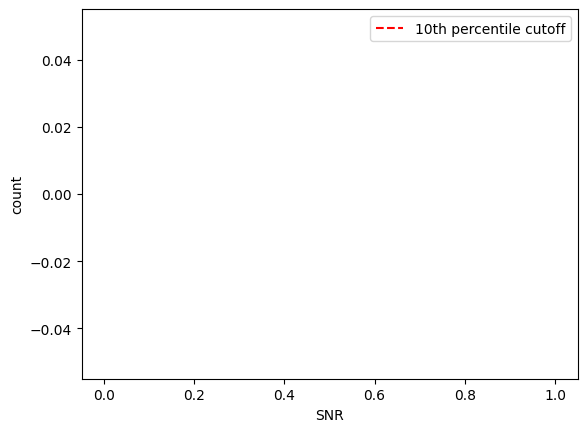

In [18]:
# Get all columns from the original table
conn = sqlite3.connect('spectra.db')
df = pd.read_sql_query("SELECT * FROM spectra", conn)
conn.close()

# Compute SNR stats
mean = df['SNR'].mean()
std = df['SNR'].std()
cutoff = df['SNR'].quantile(0.10)

# Plot SNR distribution with cutoff
plt.hist(df['SNR'].dropna().sort_values(), bins=50, alpha=0.7, color='blue')
plt.axvline(cutoff, color='r', linestyle='--', label='10th percentile cutoff')
plt.legend()
plt.xlabel('SNR')
plt.ylabel('count')
plt.show()

In [16]:
print(df['SNR'].describe())

count       0
unique      0
top       NaN
freq      NaN
Name: SNR, dtype: object


In [ ]:
# compute cutoff from the 10th percentile and filter full dataframe
cutoff = df['SNR'].quantile(0.10)
print(f"cutoff value (10th percentile): {cutoff}")

# keep only high-SNR rows in memory (all original columns retained)
cleaned = df[df['SNR'] > cutoff].copy()

# optional: make df itself the filtered table variable for downstream cells
df_filtered = cleaned

print(f"original rows: {len(df)}")
print(f"rows kept in memory (cleaned): {len(cleaned)}")
print(f"rows removed in memory: {len(df) - len(cleaned)}")

cutoff value (15th percentile): 9.323929999999999
original rows: 18100, remaining after deletion: 15385


In [17]:
# preview first 10 retained rows with all columns
display(cleaned.head(10))

,SNR
1,529.047300
2,626.448900
3,140.122400
5,112.820501
6,28.169400
7,195.799400
8,150.802500
9,26.522872
10,24.773900
11,11.449600
